# Sequential Data and RNNs

## Learning Objectives
- Understand the nature of sequential data.
- Learn the basics of Recurrent Neural Networks (RNNs) and how they handle sequences.

## Introduction
Recurrent Neural Networks (RNN) are deep learning models that capture sequences through recurrent connections. Sequential data, such as time series and natural language, requires models capable of remembering past inputs. RNNs achieve this by maintaining hidden states that evolve over time.

## Core Concepts
- **Sequence ** Ordered data points (text, speech, sensor readings).
- **RNN architecture:** Uses loops to propagate information.
- **Hidden state:** Memory that captures past information.
- **Challenges:** Vanishing and exploding gradients.

## Example
Simple RNN cell illustration.

In [1]:
import numpy as np

def simple_rnn_cell(x, h_prev, Wx, Wh, b):
    h = np.tanh(np.dot(Wx, x) + np.dot(Wh, h_prev) + b)
    return h

# Example input and previous hidden state
x = np.array([0.5, 0.1])  # input vector
h_prev = np.array([0.0, 0.0])  # initial hidden state

# Random weights and bias
Wx = np.array([[0.1, 0.2], [0.3, 0.4]])
Wh = np.array([[0.5, 0.6], [0.7, 0.8]])
b = np.array([0.1, 0.1])

h = simple_rnn_cell(x, h_prev, Wx, Wh, b)
print(f"Hidden state: {h}")

Hidden state: [0.16838105 0.28213481]


## Time Series

In [2]:
%matplotlib inline
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

Create function

In [3]:
np.random.seed(42)
tf.random.set_seed(42)

def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_steps)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))  #   wave 1
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20)) # + wave 2
    series += 0.1 * (np.random.rand(batch_size, n_steps) - 0.5)   # + noise
    return series[..., np.newaxis].astype(np.float32)

In [5]:
np.random.seed(42)

n_steps = 50
series = generate_time_series(10000, n_steps + 1)
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [6]:
X_train.shape, y_train.shape

((7000, 50, 1), (7000, 1))

Plot series

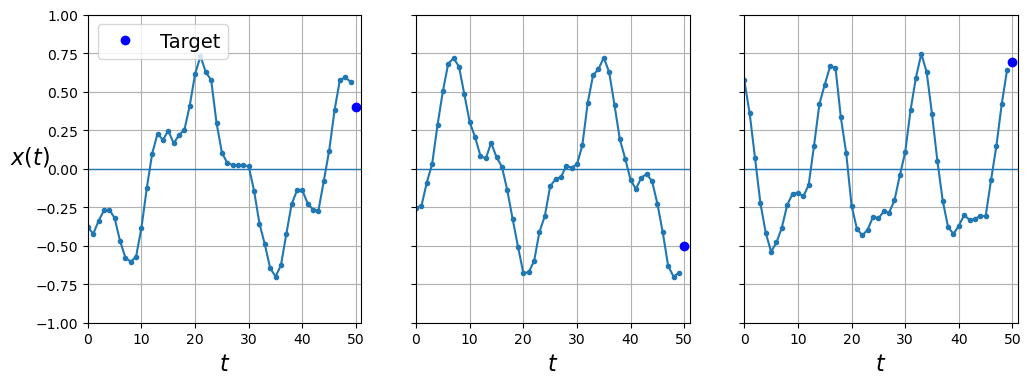

In [7]:
def plot_series(series, y=None, y_pred=None, x_label="$t$", y_label="$x(t)$", legend=True):
    plt.plot(series, ".-")
    if y is not None:
        plt.plot(n_steps, y, "bo", label="Target")
    if y_pred is not None:
        plt.plot(n_steps, y_pred, "rx", markersize=10, label="Prediction")
    plt.grid(True)
    if x_label:
        plt.xlabel(x_label, fontsize=16)
    if y_label:
        plt.ylabel(y_label, fontsize=16, rotation=0)
    plt.hlines(0, 0, 100, linewidth=1)
    plt.axis([0, n_steps + 1, -1, 1])
    if legend and (y or y_pred):
        plt.legend(fontsize=14, loc="upper left")

fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(12, 4))
for col in range(3):
    plt.sca(axes[col])
    plot_series(X_valid[col, :, 0], y_valid[col, 0],
                y_label=("$x(t)$" if col==0 else None),
                legend=(col == 0))
plt.show()

Compute baselines

In [ ]:
y_pred = X_valid[:, -1]
np.mean(keras.losses.mean_squared_error(y_valid, y_pred))

Plot

In [ ]:
plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred[0, 0])
plt.show()

Train

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[50, 1]),
    keras.layers.Dense(1)
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

Evaluate

In [ ]:
model.evaluate(X_valid, y_valid)

In [ ]:
def plot_learning_curves(loss, val_loss):
    plt.plot(np.arange(len(loss)) + 0.5, loss, "b.-", label="Training loss")
    plt.plot(np.arange(len(val_loss)) + 1, val_loss, "r.-", label="Validation loss")
    plt.gca().xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
    plt.axis([1, 20, 0, 0.05])
    plt.legend(fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True)

plot_learning_curves(history.history["loss"], history.history["val_loss"])
plt.show()

In [ ]:
y_pred = model.predict(X_valid)
plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred[0, 0])
plt.show()

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.SimpleRNN(1, input_shape=[None, 1])
])

optimizer = keras.optimizers.Adam(learning_rate=0.005)
model.compile(loss="mse", optimizer=optimizer)
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

## Exercise
Compute the hidden state for a sequence of inputs using the simple RNN cell.

In [ ]:
# Your code here

## Summary
- RNNs process sequential data by maintaining hidden states.
- Basic RNNs have limitations with long sequences due to gradient issues.


## Further Reading
- [Understanding RNNs](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)
- [Deep Learning Book - Sequence Modeling](https://www.deeplearningbook.org/contents/rnn.html)
